In [1]:
import json
import re
import numpy as np
import pandas as pd
import re
from scipy.stats import pointbiserialr, spearmanr, ttest_ind, mannwhitneyu
import pingouin as pg
from tqdm import tqdm
import rich

## Data Preparation

In [2]:
import json

with open('/data/user_data/wenkail/sotopia_diplomacy/processed_data_analysis/500_sample_with_taskeval_supply_center_qwen_judge.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

# print(data[0])

In [3]:
# Iterate over all games and filter out messages where 'llm_judgement' does not contain exactly 8 yes/no answers
# For parsing, only use the part after </think>
filtered_data = []
not_8_matches_games = []

def extract_answers_after_think(llm_judgement):
    """
    Extracts the 8 yes/no answers after </think> from the llm_judgement string.
    Returns a list of matches (should be length 8 if valid), or [] if not found.
    """
    if not isinstance(llm_judgement, str):
        return []
    # Find the part after </think>
    split = llm_judgement.split("</think>")
    if len(split) < 2:
        return []
    after_think = split[1]
    # Only use the part after </think>
    # Find all lines like "1. Yes", "2. No", etc.
    matches = re.findall(r'\d+\.\s*(yes|no)', after_think.lower())
    return matches

for game in data:
    filtered_game = json.loads(json.dumps(game))  # Deep copy
    for phase in filtered_game.get('phases', []):
        filtered_messages = []
        for msg in phase.get('messages', []):
            if 'llm_judgement' in msg:
                s = msg['llm_judgement']
                matches = extract_answers_after_think(s)
                msg['llm_judgement_matches'] = matches
                if len(matches) == 8:
                    filtered_messages.append(msg)
                else:
                    msg['llm_judgement_matches'] = None
                    not_8_matches_games.append({'game_id': game.get('id'), 'phase': phase.get('name')})
            else:
                filtered_messages.append(msg)
        phase['messages'] = filtered_messages
    filtered_data.append(filtered_game)

# Calculate the proportion of not_8_matches_games
total_messages = 0
for game in data:
    for phase in game.get('phases', []):
        total_messages += len(phase.get('messages', []))

not_8_matches_count = len(not_8_matches_games)
if total_messages > 0:
    ratio = not_8_matches_count / total_messages
else:
    ratio = 0

print(f"Number of not_8_matches_games: {not_8_matches_count}")
print(f"Total number of messages: {total_messages}")
print(f"Proportion: {ratio:.2%}")

Number of not_8_matches_games: 13283
Total number of messages: 329454
Proportion: 4.03%


In [4]:
data = filtered_data

### Non-Binary for the negotaion features without text features

In [42]:
# This is for sender-based features

# 对每个year, 针对A phase，记录所有power的supply gain（center_increase）和taskeval，
# 只收集sender为该power的message（即只统计power主动发出的message），并计算8个LLM judgement特征的sum向量（统计有多少次yes）。
# 每个power都单独作为一行，后续做相关性分析。
# 现在把该power主动发出的所有message（文本）也放入dataframe，并且放在开头的columns

import numpy as np
from scipy.stats import pearsonr, spearmanr  # <-- Added import to fix NameError

# 特征名映射
feature_name_map = {
    'feature_0_yes_sum': "1. Game-Move",
    'feature_1_yes_sum': "2. Reasoning",
    'feature_2_yes_sum': "3. Rapport",
    'feature_3_yes_sum': "4. Apologies",
    'feature_4_yes_sum': "5. Compliment",
    'feature_5_yes_sum': "6. Personal-Thoughts",
    'feature_6_yes_sum': "7. Reassurance",
    'feature_7_yes_sum': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            yes_sum = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                yes_sum[i] += 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(yes_sum) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_sum' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_sum = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_sum = df_corr_sum.rename(columns=feature_name_map)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_sum'] for i in range(8)]

for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_sum[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:           # All same value → skip
        continue

    # 相关性分析：sum特征与supply_gain的相关性
    r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
    r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])

    records.append(dict(
        feature=feat,
        pearson_r=round(r_pearson, 3),
        p_pearson=round(p_pearson, 4),
        spearman_r=round(r_spearman, 3),
        p_spearman=round(p_spearman, 4),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation summary (sum up version) ===")
print(final_df)



=== Combined correlation summary (sum up version) ===
                      pearson_r  p_pearson  spearman_r  p_spearman
feature                                                           
1. Game-Move              0.236        0.0       0.362         0.0
2. Reasoning              0.180        0.0       0.296         0.0
3. Rapport                0.200        0.0       0.290         0.0
4. Apologies              0.179        0.0       0.234         0.0
5. Compliment             0.152        0.0       0.216         0.0
6. Personal-Thoughts      0.127        0.0       0.171         0.0
7. Reassurance            0.147        0.0       0.234         0.0
8. Share-Information      0.182        0.0       0.293         0.0


In [43]:
# This is for sender-based features
# Where the prediction target is supply_center

import numpy as np

# llama-3-8b tokenizer
from transformers import AutoTokenizer

llama3_tokenizer = AutoTokenizer.from_pretrained("/data/models/huggingface/meta-llama/Llama-3.1-8B-Instruct")

# 使用nltk的句子分割
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

def count_sentences(text):
    # 使用nltk的句子分割
    if not text or not isinstance(text, str):
        return 0
    sentences = sent_tokenize(text)
    return len(sentences)

results = []
for game in tqdm(data):
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            # 跳过all_messages_str为空的情况
            if not all_messages_str.strip():
                continue
            # 计算句子数和token数
            num_sentences = count_sentences(all_messages_str)
            num_tokens = len(llama3_tokenizer.encode(all_messages_str))
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面，前面加上num_sentences, num_tokens
            results.append([num_sentences, num_tokens, all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['num_sentences', 'num_tokens', 'messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

[nltk_data] Downloading package punkt to /home/wenkail/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
100%|██████████| 471/471 [00:46<00:00, 10.17it/s]


In [47]:
# 计算所有8个特征加上num_sentences和num_tokens与supply_gain的相关性（皮尔逊和斯皮尔曼），并输出表格

from scipy.stats import pearsonr, spearmanr
import pandas as pd

# 选取所有8个特征加上num_sentences和num_tokens
selected_features = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information",
    "num_sentences", "num_tokens"
]

records = []
for feat in selected_features:
    valid = df_corr_binary[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:
        continue
    r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
    r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])
    records.append(dict(
        feature=feat,
        pearson_r=round(r_pearson, 3),
        p_pearson=round(p_pearson, 4),
        spearman_r=round(r_spearman, 3),
        p_spearman=round(p_spearman, 4),
    ))

corr_df = pd.DataFrame(records).set_index('feature')
print("\n=== Correlation summary (binary version, all features + num_sentences/num_tokens) ===")
print(corr_df)



=== Correlation summary (binary version, all features + num_sentences/num_tokens) ===
                      pearson_r  p_pearson  spearman_r  p_spearman
feature                                                           
1. Game-Move              0.159        0.0       0.167         0.0
2. Reasoning              0.147        0.0       0.154         0.0
3. Rapport                0.161        0.0       0.173         0.0
4. Apologies              0.148        0.0       0.160         0.0
5. Compliment             0.138        0.0       0.145         0.0
6. Personal-Thoughts      0.103        0.0       0.108         0.0
7. Reassurance            0.117        0.0       0.128         0.0
8. Share-Information      0.128        0.0       0.135         0.0
num_sentences             0.119        0.0       0.225         0.0
num_tokens                0.110        0.0       0.222         0.0



=== Features Correlation Matrix (Pearson) ===
                      1. Game-Move  2. Reasoning  3. Rapport  4. Apologies  \
1. Game-Move                  1.00          0.46        0.23          0.16   
2. Reasoning                  0.46          1.00        0.33          0.26   
3. Rapport                    0.23          0.33        1.00          0.61   
4. Apologies                  0.16          0.26        0.61          1.00   
5. Compliment                 0.19          0.31        0.55          0.39   
6. Personal-Thoughts          0.16          0.25        0.43          0.30   
7. Reassurance                0.23          0.40        0.58          0.41   
8. Share-Information          0.38          0.63        0.33          0.27   
num_sentences                 0.16          0.28        0.32          0.39   
num_tokens                    0.15          0.27        0.31          0.37   

                      5. Compliment  6. Personal-Thoughts  7. Reassurance  \
1. Game-Move     

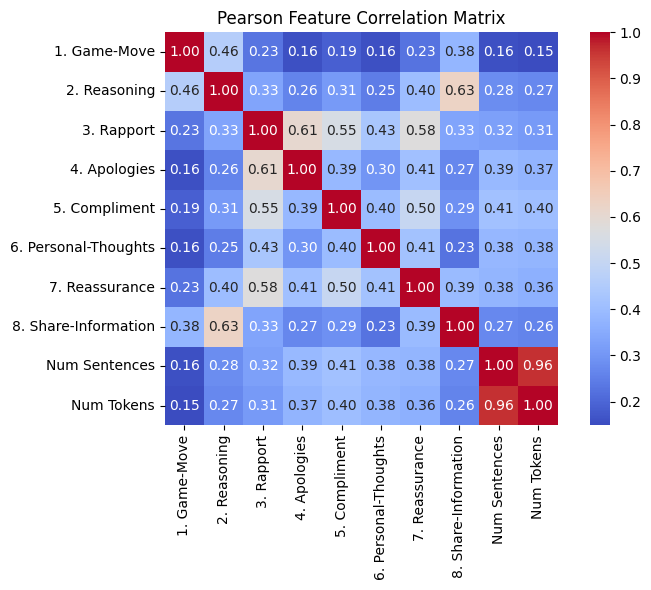

In [50]:
# 计算各个features之间的相关性，并画出相关性矩阵热力图

import matplotlib.pyplot as plt
import seaborn as sns

# 只选取8个特征（不含num_sentences/num_tokens）
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information",
    "num_sentences", "num_tokens"
]

# 对最后两个特征做label美化
feature_labels = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information",
    "Num Sentences", "Num Tokens"
]

# 计算相关性矩阵
corr_matrix = df_corr_binary[feature_cols].corr(method='pearson')

# 设置热力图的label
print("\n=== Features Correlation Matrix (Pearson) ===")
print(corr_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    square=True, 
    cbar=True,
    xticklabels=feature_labels,
    yticklabels=feature_labels
)
plt.title("Pearson Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# # 打印num_sentences和num_tokens的完整value_counts
# with pd.option_context('display.max_rows', None):
#     print("num_sentences value_counts():")
#     print(df_corr_binary['num_sentences'].value_counts())
#     print("\nnum_tokens value_counts():")
#     print(df_corr_binary['num_tokens'].value_counts())

In [56]:
df_corr_binary.head()

,num_sentences,num_tokens,messages,game_id,phase_name,power,1. Game-Move,2. Reasoning,3. Rapport,4. Apologies,5. Compliment,6. Personal-Thoughts,7. Reassurance,8. Share-Information,supply_gain,taskeval,num_sentences_bin
0,1,39,i am going right into france so i will not tak...,77032,W1901A,ENGLAND,1,1,0,0,0,0,0,1,1,-0.075030,"[1, 3)"
1,20,299,"Well hello, England. How's things? :)\r\nI hav...",77032,W1901A,FRANCE,1,1,1,0,0,0,1,1,2,0.049975,"[17, 39)"
2,10,177,Good. I'm looking forward to the game.\r\nHell...,77032,W1901A,GERMANY,1,1,1,0,1,0,1,1,2,-0.061471,"[8, 17)"
3,10,162,I agree. We should try to keep friendly with g...,77032,W1901A,ITALY,1,1,0,0,0,0,1,0,1,-0.054909,"[8, 17)"
4,23,256,Alright. I am moving to Galicia for defensive ...,77032,W1901A,AUSTRIA,1,1,0,0,0,0,1,1,1,0.019528,"[17, 39)"


=== Correlation with supply_gain under different num_sentences bins (auto-binning, Pearson & Spearman) ===

=== Correlation Table for num_sentences in [1, 3) (n=3539) ===
                      Pearson r  Pearson p  Spearman r  Spearman p
Feature                                                           
1. Game-Move              0.099     0.0000       0.111      0.0000
2. Reasoning              0.058     0.0005       0.065      0.0001
3. Rapport                0.053     0.0015       0.061      0.0003
4. Apologies             -0.002     0.9228      -0.000      0.9769
5. Compliment             0.064     0.0001       0.069      0.0000
6. Personal-Thoughts      0.057     0.0008       0.054      0.0013
7. Reassurance            0.010     0.5425       0.018      0.2811
8. Share-Information      0.003     0.8524       0.011      0.5316

=== Correlation Table for num_sentences in [3, 8) (n=5282) ===
                      Pearson r  Pearson p  Spearman r  Spearman p
Feature                     

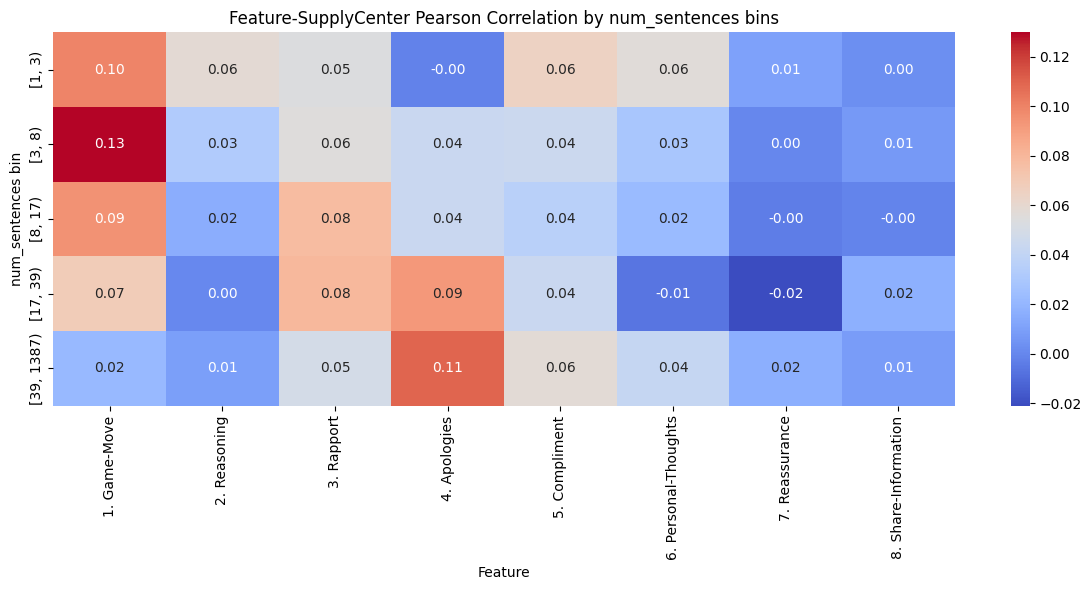

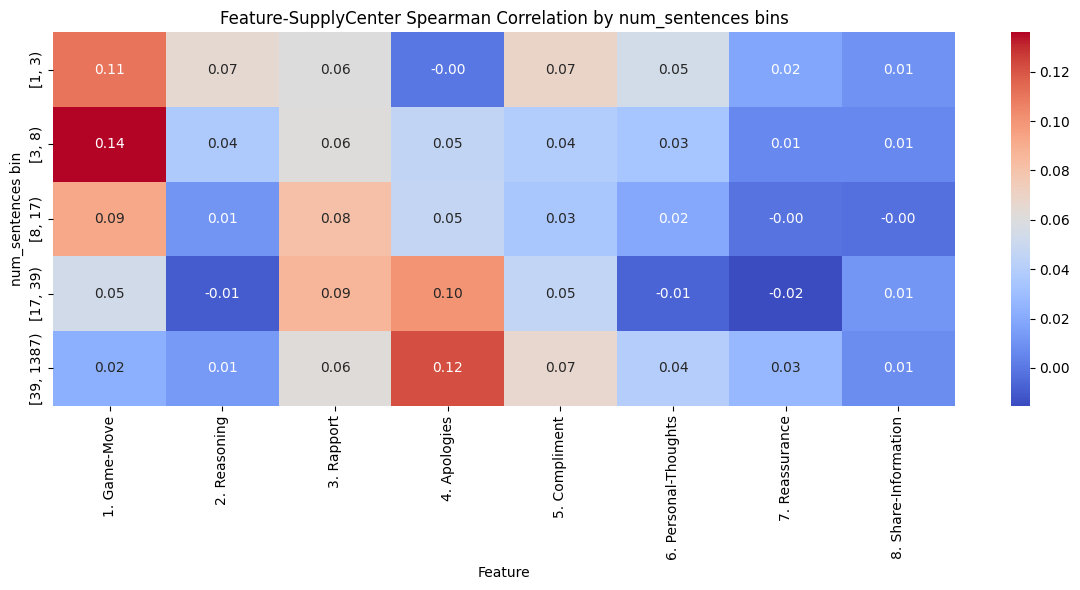

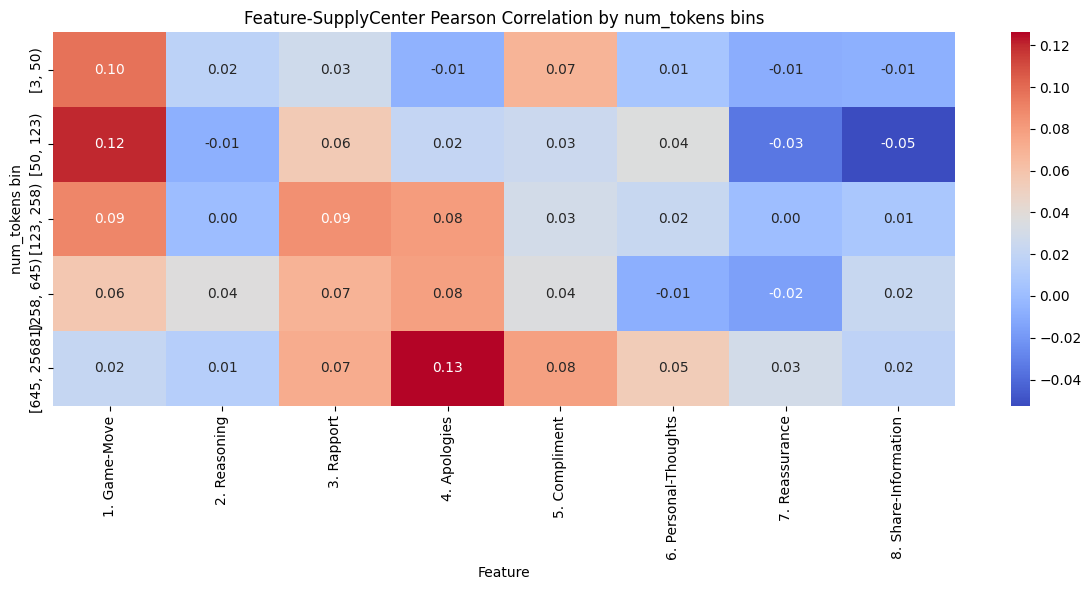

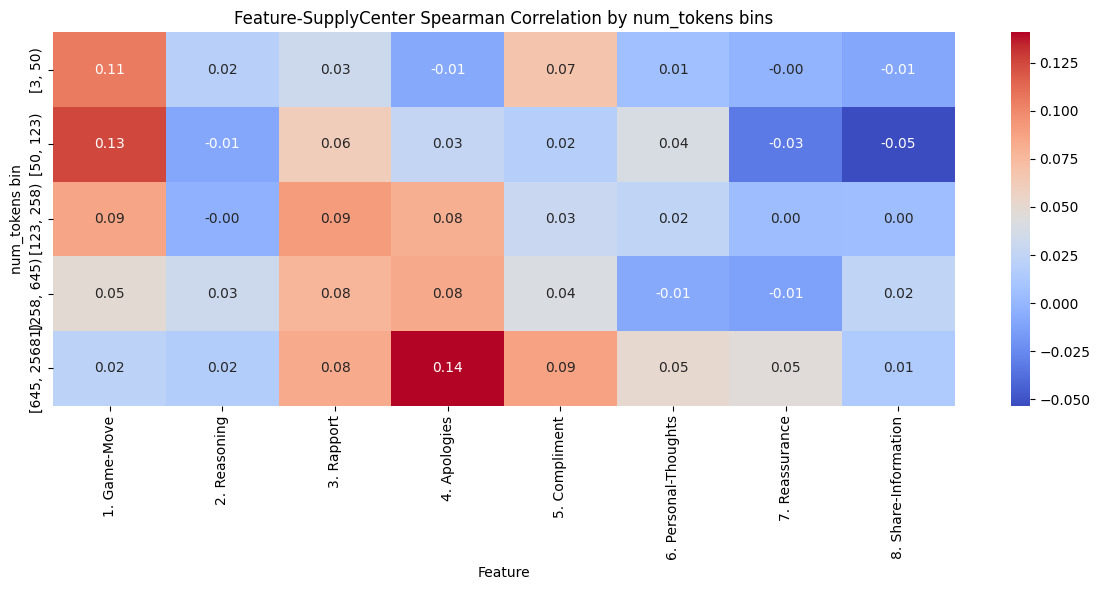

In [62]:
# For each bin, print a full correlation table (Pearson & Spearman) in English, with a different title for each bin.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import pandas as pd

feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]

# 1. Binning for num_sentences using quantiles
num_sentences_bins = np.unique(np.percentile(df_corr_binary['num_sentences'], [0, 20, 40, 60, 80, 100]).astype(int))
if len(np.unique(num_sentences_bins)) < 2:
    num_sentences_bins = [0, 2, 4, 6, 10, 100]
df_corr_binary['num_sentences_bin'] = pd.cut(df_corr_binary['num_sentences'], bins=num_sentences_bins, right=False, include_lowest=True)

print("=== Correlation with supply_gain under different num_sentences bins (auto-binning, Pearson & Spearman) ===")
corrs_sent_pearson = []
corrs_sent_spearman = []
labels_sent = []
for bin_interval in df_corr_binary['num_sentences_bin'].cat.categories:
    sub_df = df_corr_binary[df_corr_binary['num_sentences_bin'] == bin_interval]
    if len(sub_df) < 10:
        continue  # skip bins with too few samples
    # Compute correlation for each feature
    pearson_row = []
    spearman_row = []
    for feat in feature_cols:
        valid = sub_df[[feat, 'supply_gain']].dropna()
        if valid[feat].nunique() < 2:
            pearson_row.append(np.nan)
            spearman_row.append(np.nan)
            continue
        r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
        r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])
        pearson_row.append((r_pearson, p_pearson))
        spearman_row.append((r_spearman, p_spearman))
    # Build DataFrame for this bin
    corr_table = pd.DataFrame({
        "Feature": feature_cols,
        "Pearson r": [round(x[0], 3) if x is not np.nan else np.nan for x in pearson_row],
        "Pearson p": [round(x[1], 4) if x is not np.nan else np.nan for x in pearson_row],
        "Spearman r": [round(x[0], 3) if x is not np.nan else np.nan for x in spearman_row],
        "Spearman p": [round(x[1], 4) if x is not np.nan else np.nan for x in spearman_row],
    }).set_index("Feature")
    print(f"\n=== Correlation Table for num_sentences in {bin_interval} (n={len(sub_df)}) ===")
    print(corr_table)
    corrs_sent_pearson.append([x[0] if x is not np.nan else np.nan for x in pearson_row])
    corrs_sent_spearman.append([x[0] if x is not np.nan else np.nan for x in spearman_row])
    labels_sent.append(str(bin_interval))

# 2. Binning for num_tokens based on value_counts distribution
# print("\nnum_tokens value_counts (top 20):")
# print(df_corr_binary['num_tokens'].value_counts().sort_index().head(20))

num_tokens_counts = df_corr_binary['num_tokens'].value_counts().sort_index()
num_tokens_bins = np.unique(np.percentile(df_corr_binary['num_tokens'], [0, 20, 40, 60, 80, 100]).astype(int))
if len(np.unique(num_tokens_bins)) < 2:
    num_tokens_bins = [0, 20, 40, 60, 100, 1000]
df_corr_binary['num_tokens_bin'] = pd.cut(df_corr_binary['num_tokens'], bins=num_tokens_bins, right=False, include_lowest=True)

print("\n=== Correlation with supply_gain under different num_tokens bins (auto-binning, Pearson & Spearman) ===")
corrs_tok_pearson = []
corrs_tok_spearman = []
labels_tok = []
for bin_interval in df_corr_binary['num_tokens_bin'].cat.categories:
    sub_df = df_corr_binary[df_corr_binary['num_tokens_bin'] == bin_interval]
    if len(sub_df) < 10:
        continue  # skip bins with too few samples
    pearson_row = []
    spearman_row = []
    for feat in feature_cols:
        valid = sub_df[[feat, 'supply_gain']].dropna()
        if valid[feat].nunique() < 2:
            pearson_row.append(np.nan)
            spearman_row.append(np.nan)
            continue
        r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
        r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])
        pearson_row.append((r_pearson, p_pearson))
        spearman_row.append((r_spearman, p_spearman))
    corr_table = pd.DataFrame({
        "Feature": feature_cols,
        "Pearson r": [round(x[0], 3) if x is not np.nan else np.nan for x in pearson_row],
        "Pearson p": [round(x[1], 4) if x is not np.nan else np.nan for x in pearson_row],
        "Spearman r": [round(x[0], 3) if x is not np.nan else np.nan for x in spearman_row],
        "Spearman p": [round(x[1], 4) if x is not np.nan else np.nan for x in spearman_row],
    }).set_index("Feature")
    print(f"\n=== Correlation Table for num_tokens in {bin_interval} (n={len(sub_df)}) ===")
    print(corr_table)
    corrs_tok_pearson.append([x[0] if x is not np.nan else np.nan for x in pearson_row])
    corrs_tok_spearman.append([x[0] if x is not np.nan else np.nan for x in spearman_row])
    labels_tok.append(str(bin_interval))

# Visualization: Heatmap for num_sentences bins (Pearson)
if corrs_sent_pearson:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        np.array(corrs_sent_pearson), 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        xticklabels=feature_cols, 
        yticklabels=labels_sent
    )
    plt.title("Feature-SupplyCenter Pearson Correlation by num_sentences bins")
    plt.xlabel("Feature")
    plt.ylabel("num_sentences bin")
    plt.tight_layout()
    plt.show()

# Visualization: Heatmap for num_sentences bins (Spearman)
if corrs_sent_spearman:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        np.array(corrs_sent_spearman), 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        xticklabels=feature_cols, 
        yticklabels=labels_sent
    )
    plt.title("Feature-SupplyCenter Spearman Correlation by num_sentences bins")
    plt.xlabel("Feature")
    plt.ylabel("num_sentences bin")
    plt.tight_layout()
    plt.show()

# Visualization: Heatmap for num_tokens bins (Pearson)
if corrs_tok_pearson:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        np.array(corrs_tok_pearson), 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        xticklabels=feature_cols, 
        yticklabels=labels_tok
    )
    plt.title("Feature-SupplyCenter Pearson Correlation by num_tokens bins")
    plt.xlabel("Feature")
    plt.ylabel("num_tokens bin")
    plt.tight_layout()
    plt.show()

# Visualization: Heatmap for num_tokens bins (Spearman)
if corrs_tok_spearman:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        np.array(corrs_tok_spearman), 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        xticklabels=feature_cols, 
        yticklabels=labels_tok
    )
    plt.title("Feature-SupplyCenter Spearman Correlation by num_tokens bins")
    plt.xlabel("Feature")
    plt.ylabel("num_tokens bin")
    plt.tight_layout()
    plt.show()


/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


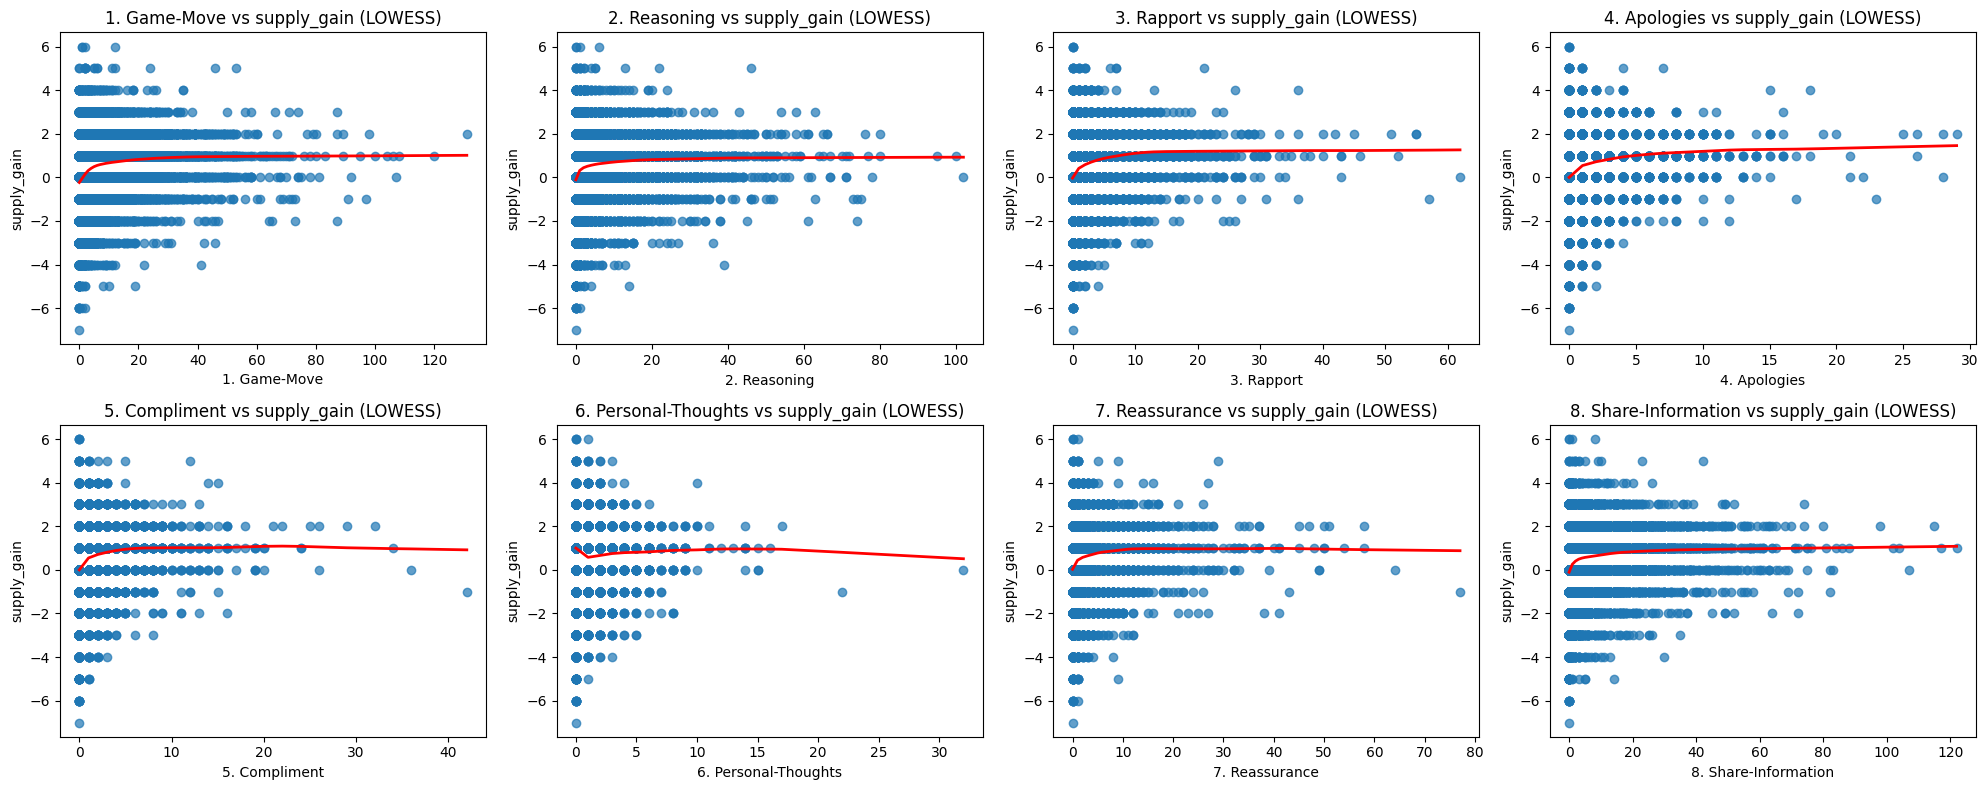

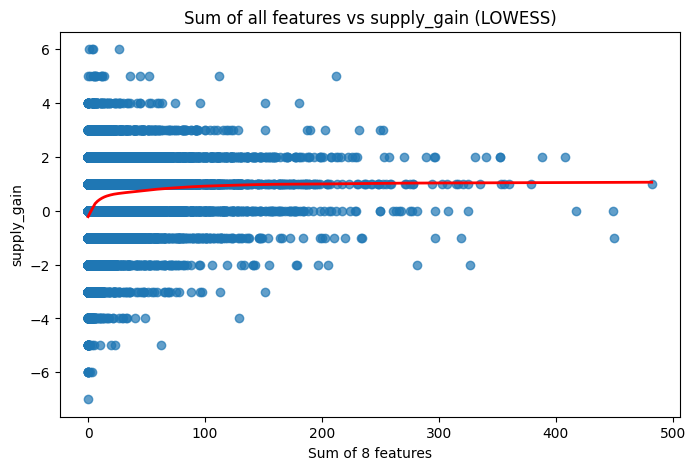

In [ ]:
# Plot distribution of features and supply_gain

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Plot each feature vs supply_gain (非线性趋势：LOWESS曲线)
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 4, idx % 4]
    # 画出每个数据点的散点图和LOWESS平滑曲线
    sns.regplot(
        x=feat, 
        y="supply_gain", 
        data=df_corr_sum, 
        ax=ax,
        scatter_kws={'alpha': 0.7},
        line_kws={'color': 'red', 'linewidth': 2},
        lowess=True,   # 关键参数：非线性拟合
        ci=None
    )
    ax.set_title(f"{feat} vs supply_gain (LOWESS)")
    ax.set_xlabel(feat)
    ax.set_ylabel("supply_gain")
plt.tight_layout()
plt.show()

# 2. Plot sum of all features vs supply_gain (非线性趋势：LOWESS曲线)
df_corr_sum["features_sum"] = df_corr_sum[feature_cols].sum(axis=1)
plt.figure(figsize=(8, 5))
sns.regplot(
    x="features_sum", 
    y="supply_gain", 
    data=df_corr_sum, 
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2},
    lowess=True,   # 关键参数：非线性拟合
    ci=None
)
plt.title("Sum of all features vs supply_gain (LOWESS)")
plt.xlabel("Sum of 8 features")
plt.ylabel("supply_gain")
plt.show()

### Binary Analysis -- Negotiation Features with text features

In [ ]:
# This is for sender-based features
# Where the prediction target is supply_center

import numpy as np

# llama-3-8b tokenizer
from transformers import AutoTokenizer

llama3_tokenizer = AutoTokenizer.from_pretrained("/data/models/huggingface/meta-llama/Llama-3.1-8B-Instruct")

# 使用nltk的句子分割
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

def count_sentences(text):
    # 使用nltk的句子分割
    if not text or not isinstance(text, str):
        return 0
    sentences = sent_tokenize(text)
    return len(sentences)

results = []
for game in tqdm(data):
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            # 跳过all_messages_str为空的情况
            if not all_messages_str.strip():
                continue
            # 计算句子数和token数
            num_sentences = count_sentences(all_messages_str)
            num_tokens = len(llama3_tokenizer.encode(all_messages_str))
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面，前面加上num_sentences, num_tokens
            results.append([num_sentences, num_tokens, all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['num_sentences', 'num_tokens', 'messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

In [28]:
df_corr_binary.tail()

,num_sentences,num_tokens,messages,game_id,phase_name,power,1. Game-Move,2. Reasoning,3. Rapport,4. Apologies,5. Compliment,6. Personal-Thoughts,7. Reassurance,8. Share-Information,supply_gain,taskeval
22525,7,70,My fleets are on standby.\nSupport me to Sevas...,90367,W1908A,TURKEY,1,0,0,0,0,0,0,0,3,-0.011222
22526,8,32,Explain this Pause thing.\r\nWhat's the Pause ...,90367,W1909A,FRANCE,0,0,0,0,0,0,0,0,-3,-0.016231
22527,3,26,"gg everyone\r\nty, we had a good alliance. Ita...",90367,W1909A,GERMANY,0,0,0,0,0,0,0,1,3,0.032379
22528,12,143,Should I head into Vienna or should I try for ...,90367,W1909A,AUSTRIA,1,1,0,0,0,0,0,1,-1,-0.001735
22529,3,24,I don't understand about trading armies. what ...,90367,W1909A,TURKEY,1,0,0,0,0,0,0,0,1,-0.041923


In [7]:
# This is for recipient-side analysis
# Where the prediction target is supply_center
import numpy as np

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集recipient为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑recipient为该power的message
                    if msg.get('recipient') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_binary'] for i in range(8)]

for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_binary[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:           # All 0 or all 1 → skip
        continue

    x_yes = valid.loc[valid[feat] == 1, 'supply_gain']
    x_no  = valid.loc[valid[feat] == 0, 'supply_gain']

    # --- Linear / rank correlation ---
    r_pb, p_pb = pointbiserialr(valid[feat], valid['supply_gain'])
    r_sp, p_sp = spearmanr(valid[feat], valid['supply_gain'])

    # --- Welch t-test & Cohen’s d ---
    t_stat, p_t = ttest_ind(x_yes, x_no, equal_var=False)
    d = pg.compute_effsize(x_yes, x_no, eftype='cohen')

    # --- Mann-Whitney U & Rank-biserial r ---
    u_stat, p_u = mannwhitneyu(x_yes, x_no, alternative='two-sided')
    r_rb = 1 - 2 * u_stat / (len(x_yes) * len(x_no))

    # --- Cliff’s δ ---
    # delta = pg.compute_effsize(x_yes, x_no, eftype='cliff')

    records.append(dict(
        feature=feat,
        point_biserial_r=round(r_pb, 3),
        p_pb=round(p_pb, 4),
        spearman_r=round(r_sp, 3),
        p_sp=round(p_sp, 4),
        welch_t=round(t_stat, 3),
        p_t=round(p_t, 4),
        cohen_d=round(d, 3),
        mannwhitney_u=int(u_stat),
        p_u=round(p_u, 4),
        rank_biserial_r=round(r_rb, 3),
        # cliffs_delta=round(delta, 3),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation & effect-size summary ===")
print(final_df)



=== Combined correlation & effect-size summary ===
                      point_biserial_r  p_pb  spearman_r  p_sp  welch_t  p_t  \
feature                                                                        
1. Game-Move                     0.273   0.0       0.305   0.0   52.424  0.0   
2. Reasoning                     0.238   0.0       0.266   0.0   42.715  0.0   
3. Rapport                       0.221   0.0       0.247   0.0   38.816  0.0   
4. Apologies                     0.197   0.0       0.216   0.0   34.653  0.0   
5. Compliment                    0.159   0.0       0.179   0.0   27.731  0.0   
6. Personal-Thoughts             0.078   0.0       0.091   0.0   13.169  0.0   
7. Reassurance                   0.193   0.0       0.216   0.0   33.714  0.0   
8. Share-Information             0.241   0.0       0.269   0.0   43.409  0.0   

                      cohen_d  mannwhitney_u  p_u  rank_biserial_r  
feature                                                             
1. Game-M

In [34]:
# This is for recipient-side analysis
# Where the prediction target is supply_center_binary

import numpy as np

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集recipient为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑recipient为该power的message
                    if msg.get('recipient') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

# ---------------------------------------------------
# 新增：生成二元的supply_center_binary列，作为prediction的目标
# 规则：只要supply_gain > 0，则为1，否则为0
df_corr_binary['supply_center_binary'] = (df_corr_binary['supply_gain'] > 0).astype(int)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_binary'] for i in range(8)]

# 下面的分析目标变量改为supply_center_binary
for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_binary[[feat, 'supply_center_binary']].dropna()
    if valid[feat].nunique() < 2:           # All 0 or all 1 → skip
        continue

    x_yes = valid.loc[valid[feat] == 1, 'supply_center_binary']
    x_no  = valid.loc[valid[feat] == 0, 'supply_center_binary']

    # --- Linear / rank correlation ---
    r_pb, p_pb = pointbiserialr(valid[feat], valid['supply_center_binary'])
    r_sp, p_sp = spearmanr(valid[feat], valid['supply_center_binary'])

    # --- Welch t-test & Cohen’s d ---
    t_stat, p_t = ttest_ind(x_yes, x_no, equal_var=False)
    d = pg.compute_effsize(x_yes, x_no, eftype='cohen')

    # --- Mann-Whitney U & Rank-biserial r ---
    u_stat, p_u = mannwhitneyu(x_yes, x_no, alternative='two-sided')
    r_rb = 1 - 2 * u_stat / (len(x_yes) * len(x_no))

    # --- Cliff’s δ ---
    # delta = pg.compute_effsize(x_yes, x_no, eftype='cliff')

    records.append(dict(
        feature=feat,
        point_biserial_r=round(r_pb, 3),
        p_pb=round(p_pb, 4),
        spearman_r=round(r_sp, 3),
        p_sp=round(p_sp, 4),
        welch_t=round(t_stat, 3),
        p_t=round(p_t, 4),
        cohen_d=round(d, 3),
        mannwhitney_u=int(u_stat),
        p_u=round(p_u, 4),
        rank_biserial_r=round(r_rb, 3),
        # cliffs_delta=round(delta, 3),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation & effect-size summary (target: supply_center_binary) ===")
print(final_df)



=== Combined correlation & effect-size summary (target: supply_center_binary) ===
                      point_biserial_r  p_pb  spearman_r  p_sp  welch_t  p_t  \
feature                                                                        
1. Game-Move                     0.365   0.0       0.365   0.0   80.895  0.0   
2. Reasoning                     0.310   0.0       0.310   0.0   58.073  0.0   
3. Rapport                       0.282   0.0       0.282   0.0   49.866  0.0   
4. Apologies                     0.235   0.0       0.235   0.0   40.157  0.0   
5. Compliment                    0.203   0.0       0.203   0.0   34.536  0.0   
6. Personal-Thoughts             0.122   0.0       0.122   0.0   20.590  0.0   
7. Reassurance                   0.250   0.0       0.250   0.0   43.266  0.0   
8. Share-Information             0.313   0.0       0.313   0.0   58.905  0.0   

                      cohen_d  mannwhitney_u  p_u  rank_biserial_r  
feature                                        

In [35]:
df_corr_binary.head()

,messages,game_id,phase_name,power,1. Game-Move,2. Reasoning,3. Rapport,4. Apologies,5. Compliment,6. Personal-Thoughts,7. Reassurance,8. Share-Information,supply_gain,taskeval,supply_center_binary
0,"Well hello, England. How's things? :)\r\nWe ha...",77032,W1901A,ENGLAND,1,0,1,0,1,0,1,1,1,-0.075030,1
1,What are your plans with England and Germany? ...,77032,W1901A,FRANCE,1,1,1,0,0,0,1,1,2,0.049975,1
2,"Well hello, Germany. How's things? :)\r\nI hop...",77032,W1901A,GERMANY,1,1,0,0,0,0,1,1,2,-0.061471,1
3,Would you like to coordinate an early assault ...,77032,W1901A,ITALY,1,1,1,0,1,0,1,1,1,-0.054909,1
4,"Hello sir. In my experience, Turkey is one of ...",77032,W1901A,AUSTRIA,1,1,1,0,0,0,1,1,1,0.019528,1


In [36]:
# 获取所有唯一的game_id，并写入txt文件
unique_game_ids = df_corr_binary['game_id'].dropna().unique()
unique_game_ids = sorted(map(str, unique_game_ids))  # 转为字符串并排序

with open("unique_game_ids.txt", "w") as f:
    for gid in unique_game_ids:
        f.write(f"{gid}\n")

print(f"已将{len(unique_game_ids)}个唯一game_id写入unique_game_ids.txt")


已将471个唯一game_id写入unique_game_ids.txt


### Distribution Plot

=== 每个feature的0/1比例（排除message, game_id, phase_name, power）===
                      0_ratio  1_ratio
1. Game-Move            0.310    0.690
2. Reasoning            0.436    0.564
3. Rapport              0.571    0.429
4. Apologies            0.743    0.257
5. Compliment           0.754    0.246
6. Personal-Thoughts    0.807    0.193
7. Reassurance          0.629    0.371
8. Share-Information    0.431    0.569


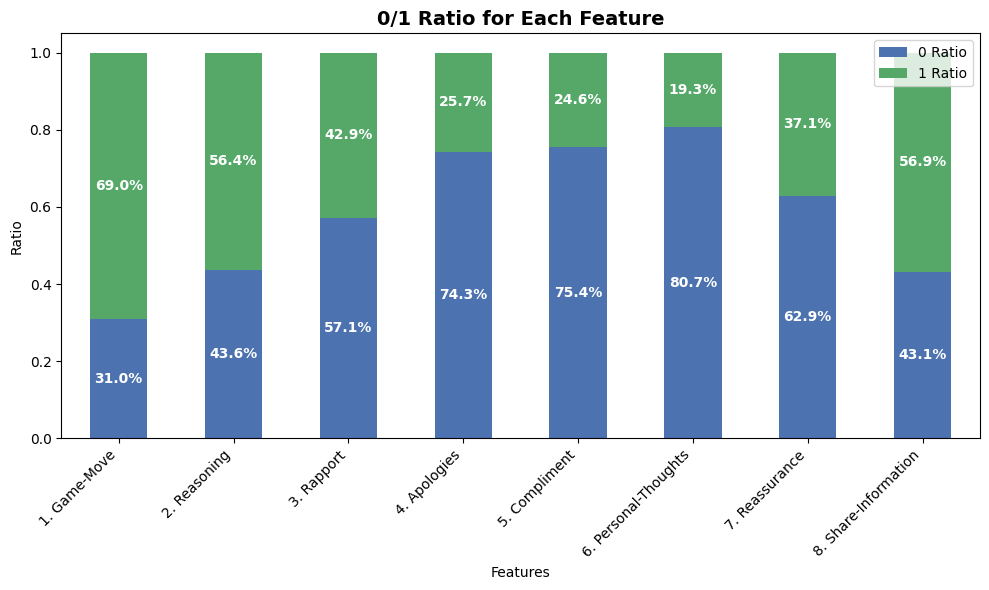

In [20]:
# 排除掉 message, game_id, phase_name, power 这四个columns，只针对剩下的二元特征列计算0/1比例并画bar plot，并在bar上写上百分比
import matplotlib.pyplot as plt
import pandas as pd

exclude_cols = {'messages', 'game_id', 'phase_name', 'power', 'supply_gain', 'taskeval'}
feature_cols = [col for col in df_corr_binary.columns if col not in exclude_cols]
feature_ratios = {}

for feat in feature_cols:
    counts = df_corr_binary[feat].value_counts(dropna=False)
    total = counts.sum()
    ratio_0 = counts.get(0, 0) / total
    ratio_1 = counts.get(1, 0) / total
    feature_ratios[feat] = {'0_ratio': round(ratio_0, 3), '1_ratio': round(ratio_1, 3)}

feature_ratio_df = pd.DataFrame(feature_ratios).T
print("=== 每个feature的0/1比例（排除message, game_id, phase_name, power）===")
print(feature_ratio_df)

# 画bar plot，并在bar上写上百分比
ax = feature_ratio_df[['0_ratio', '1_ratio']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4C72B0', '#55A868'])
plt.title("0/1 Ratio for Each Feature", fontsize=14, fontweight='bold')
plt.ylabel("Ratio")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.legend(["0 Ratio", "1 Ratio"])
plt.tight_layout()

# 在bar上写上百分比
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%', 
                        (bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.show()


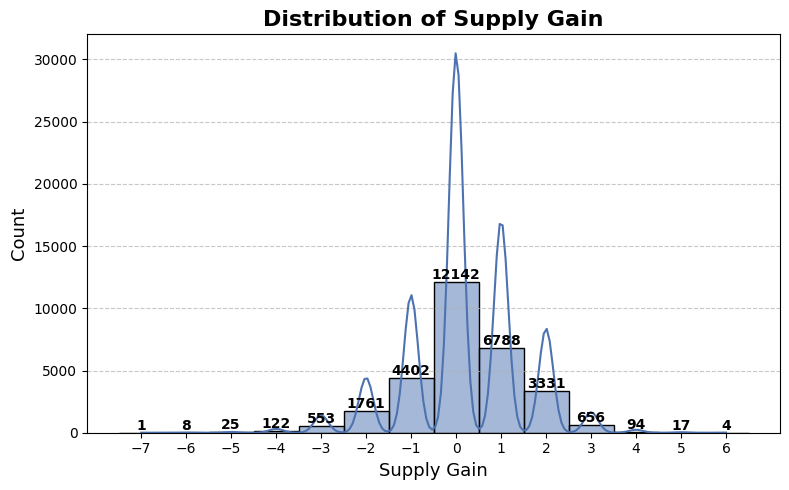

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))

# 只取非空整数的supply_gain
supply_gain = df_corr_binary["supply_gain"].dropna()
# 取所有出现过的整数
min_val = int(np.floor(supply_gain.min()))
max_val = int(np.ceil(supply_gain.max()))
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)  # 以0.5为边界，确保每个整数为一个bin

ax = sns.histplot(supply_gain, bins=bins, kde=True, color="#4C72B0", edgecolor="black", discrete=True)
plt.title("Distribution of Supply Gain", fontsize=16, fontweight='bold')
plt.xlabel("Supply Gain", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 设置x轴为整数
ax.set_xticks(range(min_val, max_val + 1))

# 在bar顶端标上数字
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2, height), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


## Classifier & Correlation Exploration

### XGBoost

In [14]:
df_corr_binary.head()

,messages,game_id,phase_name,power,1. Game-Move,2. Reasoning,3. Rapport,4. Apologies,5. Compliment,6. Personal-Thoughts,7. Reassurance,8. Share-Information,supply_gain,taskeval,supply_center_binary
0,"Well hello, England. How's things? :)\r\nWe ha...",77032,W1901A,ENGLAND,1,0,1,0,1,0,1,1,1,-0.075030,1
1,What are your plans with England and Germany? ...,77032,W1901A,FRANCE,1,1,1,0,0,0,1,1,2,0.049975,1
2,"Well hello, Germany. How's things? :)\r\nI hop...",77032,W1901A,GERMANY,1,1,0,0,0,0,1,1,2,-0.061471,1
3,Would you like to coordinate an early assault ...,77032,W1901A,ITALY,1,1,1,0,1,0,1,1,1,-0.054909,1
4,"Hello sir. In my experience, Turkey is one of ...",77032,W1901A,AUSTRIA,1,1,1,0,0,0,1,1,1,0.019528,1


/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [06:24:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 0.060357799699046984

Classification Report:
              precision    recall  f1-score   support

          -6       0.00      0.50      0.00         2
          -5       0.00      0.20      0.00         5
          -4       0.00      0.04      0.01        24
          -3       0.02      0.02      0.02       111
          -2       0.08      0.01      0.02       352
          -1       0.14      0.01      0.02       880
           0       0.30      0.00      0.00      2429
           1       0.30      0.09      0.14      1358
           2       0.21      0.31      0.25       666
           3       0.04      0.06      0.04       131
           4       0.00      0.05      0.01        19
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1

    accuracy                           0.06      5981
   macro avg       0.08      0.10      0.04      5981
weighted avg       0.24      0.06      0.07      5981



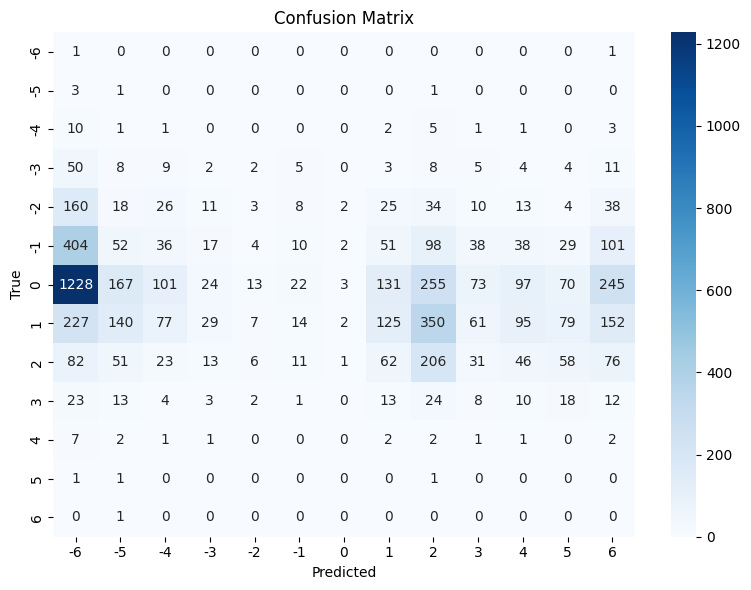

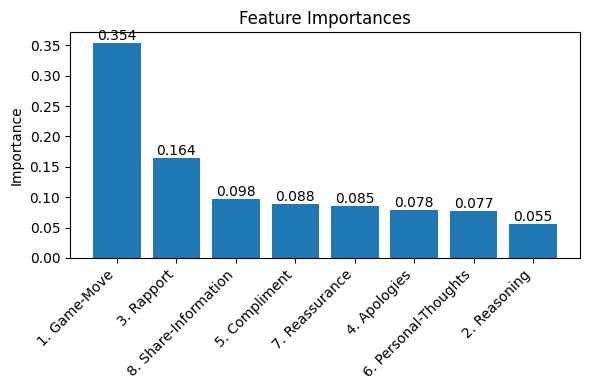

In [15]:
import pandas as pd
import numpy as np

from sklearn.preprocessing       import LabelEncoder
from sklearn.model_selection     import train_test_split
from sklearn.utils.class_weight  import compute_class_weight
from sklearn.metrics             import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = df_corr_binary.copy()
# 1) 准备数据
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]

X = df[feature_cols]
y = df["supply_gain"].astype(int)

# 过滤掉样本数小于2的类别，避免train_test_split stratify报错
value_counts = y.value_counts()
valid_classes = value_counts[value_counts >= 2].index
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask].reset_index(drop=True)
X = X.reset_index(drop=True)

# 把离散的 supply_gain 编码成 0…K-1
le      = LabelEncoder()
y_enc   = le.fit_transform(y)
classes = le.classes_               # e.g. array([-7,-6,…,6])

# 2) 划分训练/测试集（保持每个类别比例）
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

# 3) 计算样本权重以缓解类别不平衡
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
# 将每个样本的权重按其类别映射出来
sample_weights = class_weights[y_train]

# 4) 训练 XGBoost 多分类模型
clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(classes),
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)
clf.fit(X_train, y_train, sample_weight=sample_weights)

# 5) 在测试集上预测并评估
y_pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in classes]
))

# 6) 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=classes, yticklabels=classes,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 7) 特征重要性
importances = clf.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6,4))
bars = plt.bar(fi.index, fi.values)
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [06:24:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy : 0.621133589700719

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.46      0.61      3803
           1       0.49      0.90      0.63      2178

    accuracy                           0.62      5981
   macro avg       0.69      0.68      0.62      5981
weighted avg       0.74      0.62      0.62      5981



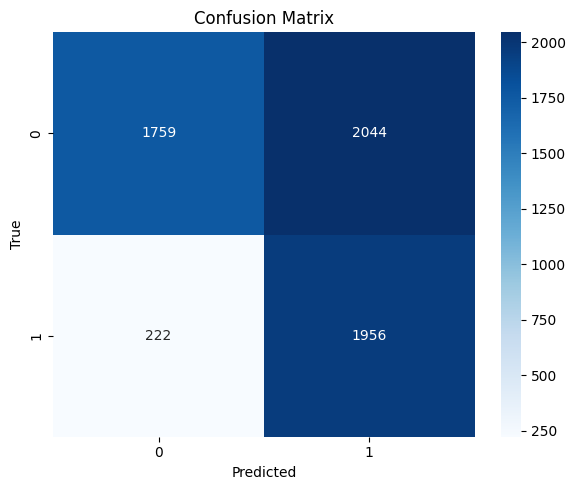

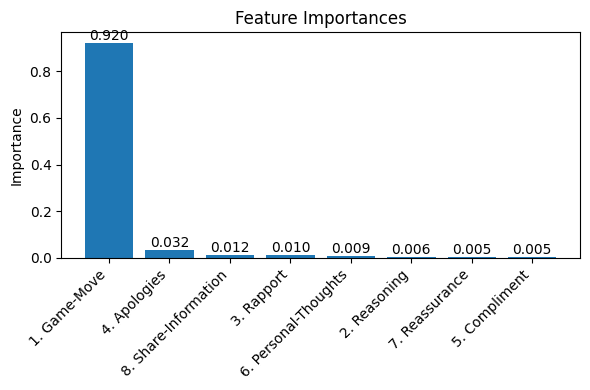

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection     import train_test_split
from sklearn.utils.class_weight  import compute_class_weight
from sklearn.metrics             import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = df_corr_binary.copy()
# 1) 准备数据
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]

X = df[feature_cols]
y = df["supply_center_binary"].astype(int)

# 过滤掉样本数小于2的类别，避免train_test_split stratify报错
value_counts = y.value_counts()
valid_classes = value_counts[value_counts >= 2].index
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask].reset_index(drop=True)
X = X.reset_index(drop=True)

classes = np.sort(y.unique())

# 2) 划分训练/测试集（保持每个类别比例）
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3) 计算样本权重以缓解类别不平衡
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
# 将每个样本的权重按其类别映射出来
sample_weights = class_weights[y_train.values]

# 4) 训练 XGBoost 二分类模型
clf = xgb.XGBClassifier(
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
clf.fit(X_train, y_train, sample_weight=sample_weights)

# 5) 在测试集上预测并评估
y_pred = clf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in classes]
))

# 6) 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=classes, yticklabels=classes,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 7) 特征重要性（bar上加数值）
importances = clf.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6,4))
bars = plt.bar(fi.index, fi.values)
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


### Logistic Regression & BernoulliNB

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report, accuracy_score
from tqdm import tqdm

import warnings
import sys
import io

output_buffer = io.StringIO()
sys_stdout = sys.stdout
sys.stderr.flush()
sys.stdout.flush()
sys.stdout = output_buffer

# GPU加速相关：使用cuML的RandomForestClassifier和cuML的LogisticRegression
try:
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.linear_model import LogisticRegression as cuLR
    cuml_available = True
except ImportError:
    print("cuML未安装，部分模型无法使用GPU加速。")
    cuml_available = False

# —— 1. 用 supply_center_correlation.ipynb 里的数据 —— #
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]
X = df[feature_cols]
y = df["supply_center_binary"]

# 分层拆分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# —— 2. 构建交叉特征生成器 —— #
poly = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

# —— 3. 定义基模型流水线 —— #
estimators = [
    ("bnb", BernoulliNB()),
]

# LogisticRegression GPU加速
if cuml_available:
    estimators.append(
        ("lr", Pipeline([
            ("poly", poly),
            ("clf", cuLR(
                penalty="l1",
                solver="qn",
                C=1.0,
                max_iter=1000,
                random_state=42,
                output_type="numpy"
            ))
        ]))
    )
else:
    estimators.append(
        ("lr", Pipeline([
            ("poly", poly),
            ("clf", LogisticRegression(
                penalty="l1",
                solver="saga",
                C=1.0,
                max_iter=1000,
                random_state=42,
                n_jobs=1,
                verbose=1
            ))
        ]))
    )

# RandomForest GPU加速
if cuml_available:
    estimators.append(
        ("rf", cuRF(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_streams=1,
            output_type="numpy"
        ))
    )
else:
    from sklearn.ensemble import RandomForestClassifier
    estimators.append(
        ("rf", RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=1,
            verbose=1
        ))
    )

# LightGBM GPU加速
estimators.append(
    ("lgb", LGBMClassifier(
        n_estimators=50,
        learning_rate=0.1,
        random_state=42,
        force_row_wise=True,
        n_jobs=1,
        device="cpu",
        verbose=1
    ))
)

# —— 4. 构建 Stacking 融合模型 —— #
if cuml_available:
    final_est = cuLR(solver="qn", output_type="numpy", max_iter=500)
else:
    final_est = LogisticRegression(solver="lbfgs", max_iter=500, n_jobs=1, verbose=1)

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    passthrough=True,
    n_jobs=1
)

print("开始训练融合模型…（如卡住可尝试重启kernel，或减少数据量/模型复杂度）")

class TqdmStackingClassifier(StackingClassifier):
    def fit(self, X, y, **fit_params):
        print("Stacking fit: 进度条显示每个一级模型的训练进度")
        for name, est in tqdm(self.estimators, desc="一级模型训练", leave=False):
            try:
                est.fit(X, y)
            except Exception as e:
                print(f"模型 {name} 训练异常: {e}")
        return super().fit(X, y, **fit_params)

stack_with_progress = TqdmStackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    passthrough=True,
    n_jobs=1
)

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stack_with_progress.fit(X_train, y_train)
except KeyboardInterrupt:
    print("训练被手动中断。可以尝试减少模型复杂度、降低max_iter、减少数据量等。")
except Exception as e:
    print(f"训练过程中出现异常: {e}")

# 在测试集上预测概率、类别，并计算 AUC 和 F1
try:
    y_pred_proba = stack_with_progress.predict_proba(X_test)[:,1]
    y_pred = stack_with_progress.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    print(f"Stacking AUC = {auc:.4f}")
    print(f"Stacking F1 = {f1:.4f}")
    print(f"Stacking Accuracy = {acc:.4f}")
    print("Stacking Classification Report:")
    print(classification_report(y_test, y_pred))
except Exception as e:
    print(f"预测或AUC/F1计算异常: {e}")

# —— 6. 单模型对比（可选） —— #
print("单模型AUC/F1对比（带进度条）:")
for name, model in tqdm(estimators, desc="单模型训练", leave=False):
    try:
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:,1]
        pred = model.predict(X_test)
        auc = roc_auc_score(y_test, proba)
        f1 = f1_score(y_test, pred)
        acc = accuracy_score(y_test, pred)
        print(f"{name:>4s} AUC = {auc:.4f} | F1 = {f1:.4f} | Acc = {acc:.4f}")
        print(f"{name:>4s} Classification Report:")
        print(classification_report(y_test, pred))
    except Exception as e:
        print(f"{name:>4s} 训练或预测异常: {e}")

# 恢复stdout
sys.stdout.flush()
sys.stdout = sys_stdout

# 将output写入文件
with open("stacking_results.txt", "w", encoding="utf-8") as f:
    f.write(output_buffer.getvalue())
output_buffer.close()


一级模型训练:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1, change: 1.00000000
Epoch 2, change: 0.20909618
Epoch 3, change: 0.14839769
Epoch 4, change: 0.08127134
Epoch 5, change: 0.05414122
Epoch 6, change: 0.03687264
Epoch 7, change: 0.01807309
Epoch 8, change: 0.01690258
Epoch 9, change: 0.01155054
Epoch 10, change: 0.00668237
Epoch 11, change: 0.00570423
Epoch 12, change: 0.00357926
Epoch 13, change: 0.00294112
Epoch 14, change: 0.00210322


一级模型训练:  50%|█████     | 2/4 [00:00<00:00,  4.54it/s]

Epoch 15, change: 0.00185652
Epoch 16, change: 0.00133328
Epoch 17, change: 0.00120720
Epoch 18, change: 0.00080040
Epoch 19, change: 0.00072319
Epoch 20, change: 0.00047611
Epoch 21, change: 0.00044080
Epoch 22, change: 0.00036231
Epoch 23, change: 0.00024385
Epoch 24, change: 0.00022342
Epoch 25, change: 0.00016600
Epoch 26, change: 0.00013965
Epoch 27, change: 0.00010679


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s


...

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
 This problem is unconstrained.
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
单模型训练:   0%|          | 0/4 [00:00<?, ?it/s]

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.93147D-01    |proj g|=  1.35832D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   13     22     25      1     0     0   7.314D-05   5.713D-01
  F =  0.57132424931753045     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
Epoch 1, change: 1.00000000
Epoch 2, change: 0.20909618
Epoch 3, change: 0.14839769
Epoch 4, change: 0.08127134
Epoch 5, change: 0.05414122
Epoch 6, change: 0.03687264
Epoch 7, change: 0.0180730

单模型训练:  50%|█████     | 2/4 [00:00<00:00,  4.30it/s]

Epoch 20, change: 0.00047611
Epoch 21, change: 0.00044080
Epoch 22, change: 0.00036231
Epoch 23, change: 0.00024385
Epoch 24, change: 0.00022342
Epoch 25, change: 0.00016600
Epoch 26, change: 0.00013965
Epoch 27, change: 0.00010679


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
